In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys

sys.path.append("../")

from tqdm import tqdm_notebook
from src import NesterovMUFunc, Nesterov, STM


In [2]:
class NesterovMUFuncEnemy(NesterovMUFunc):

    # def estimation_grad(self, x, direction_point, x_star):
    #     g = self.grad(x)
    #     size = self.alpha * np.linalg.norm(g)
    #     diff = direction_point - x_star
    #     noise = diff / np.linalg.norm(diff) * size
    #     est = g - noise
    #     return est

    def make_noise(self, x):
        noise = np.random.randn(self.d)
        g = self.grad(x)
        return np.linalg.norm(g) * self.alpha * noise / np.linalg.norm(noise)

    def estimation_grad(self, x, *args, **kwargs):
        return self.grad(x) + self.make_noise(x)


In [16]:
def plot(iters: int = 100, alpha = 0.1, mu = 1, L = 10):
    d = 1001
    start = np.zeros(d)
    start[0] = 1000
    
    with sns.plotting_context("notebook"), sns.axes_style("darkgrid"):
        plt.figure(figsize=(20, 8), dpi=120)
        nesterov = NesterovMUFuncEnemy(L=L, mu=mu, alpha=alpha, d=d)
        heavy = Nesterov(start=start, L=L, mu=mu, func=nesterov)
        stm = STM(start=start, L=L, mu=mu, func=nesterov)

        nesterov_true = NesterovMUFuncEnemy(L=L, mu=mu, alpha=0, d=d)
        heavy_true = Nesterov(start=start, L=L, mu=mu, func=nesterov_true)
        stm_true = STM(start=start, L=L, mu=mu, func=nesterov_true)

        for _ in tqdm_notebook(range(iters)):
            heavy.step()
            stm.step()
            heavy_true.step()
            stm_true.step()
        xs = heavy.history
        x_stm = stm.history
        xst = heavy_true.history
        x_stm_true = stm_true.history
        values = [nesterov(x) for x in xs]
        plt.semilogy(np.arange(len(xs)), values, label="Noised Nesterov")
        plt.semilogy(np.arange(len(xs)), [nesterov(x) for x in xst], label="Real Nesterov")
        plt.semilogy(np.arange(len(xs)), [nesterov(x) for x in x_stm], label="Noised STM")
        plt.semilogy(np.arange(len(xs)), [nesterov(x) for x in x_stm_true], label="Real STM")
        
        plt.xlabel(r"Iterations $N$")
        plt.ylabel(r"$f(x^N) - f^*$")
        plt.title(fr"$\alpha$ = {alpha:.3f}, $\mu$ = {mu:.3f}, $L$ = {L}")
        plt.legend()
    return xs

/tmp/ipykernel_132021/3790122611.py:16: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for _ in tqdm_notebook(range(iters)):


  0%|          | 0/1000 [00:00<?, ?it/s]

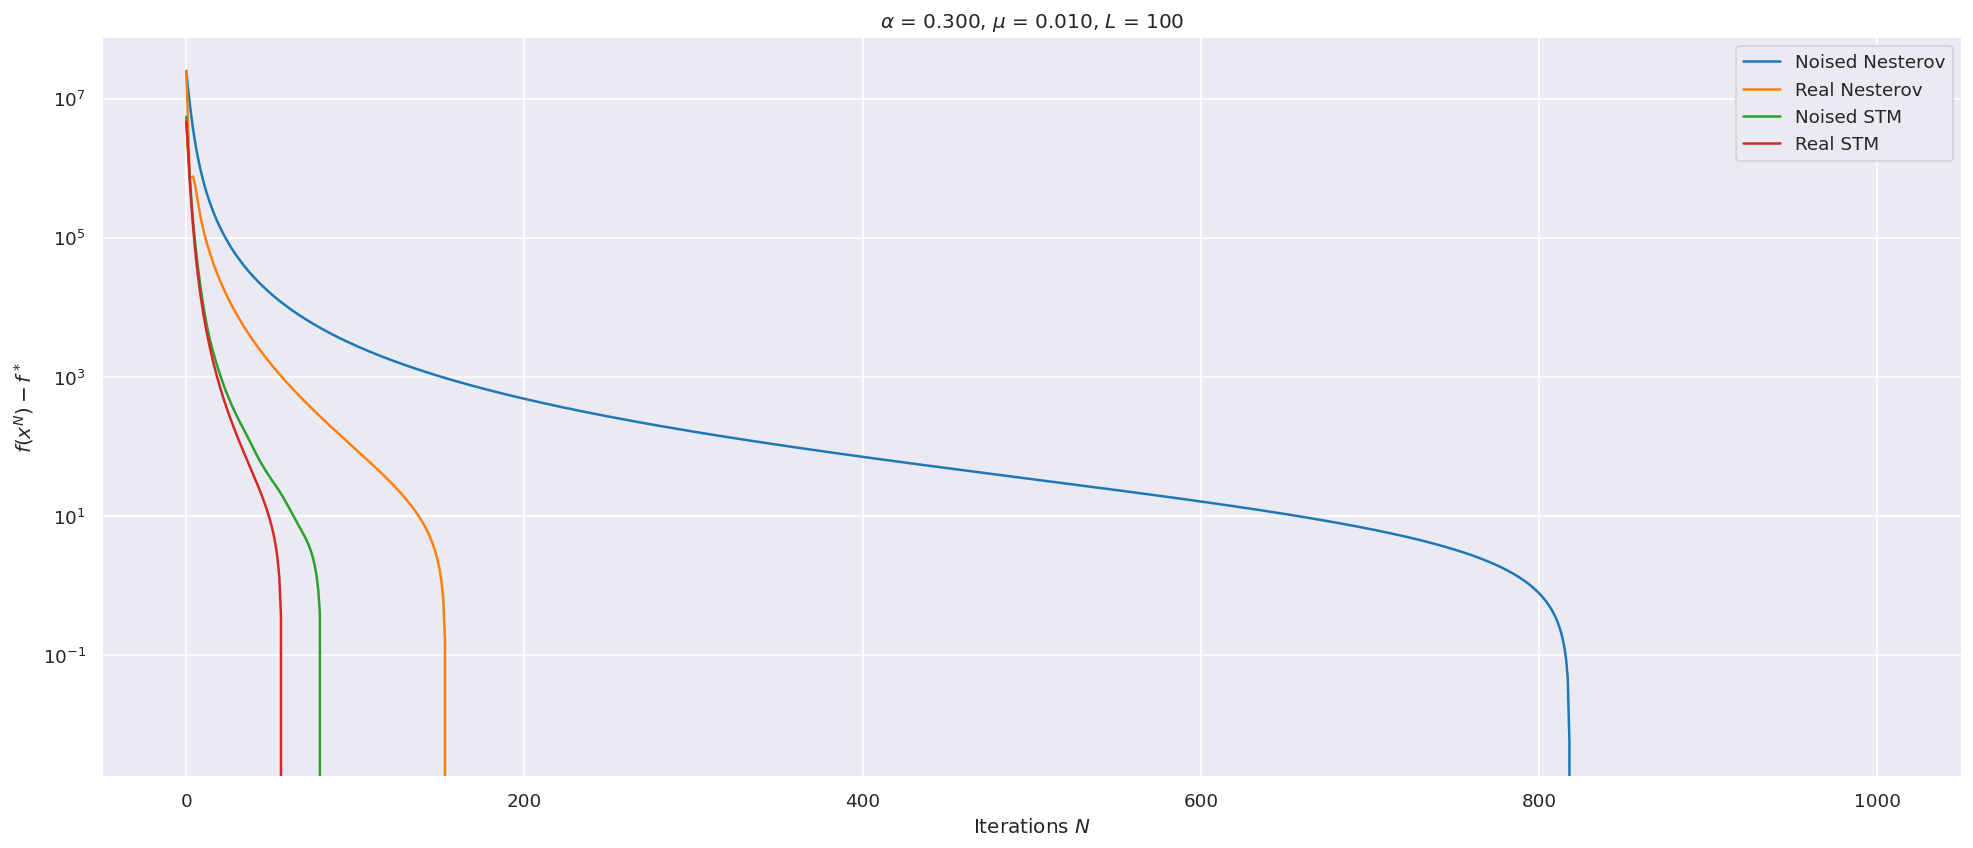

In [17]:
_ = plot(1000, alpha=0.3, mu=0.01, L=100)

/tmp/ipykernel_132021/3790122611.py:16: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for _ in tqdm_notebook(range(iters)):


  0%|          | 0/1000 [00:00<?, ?it/s]

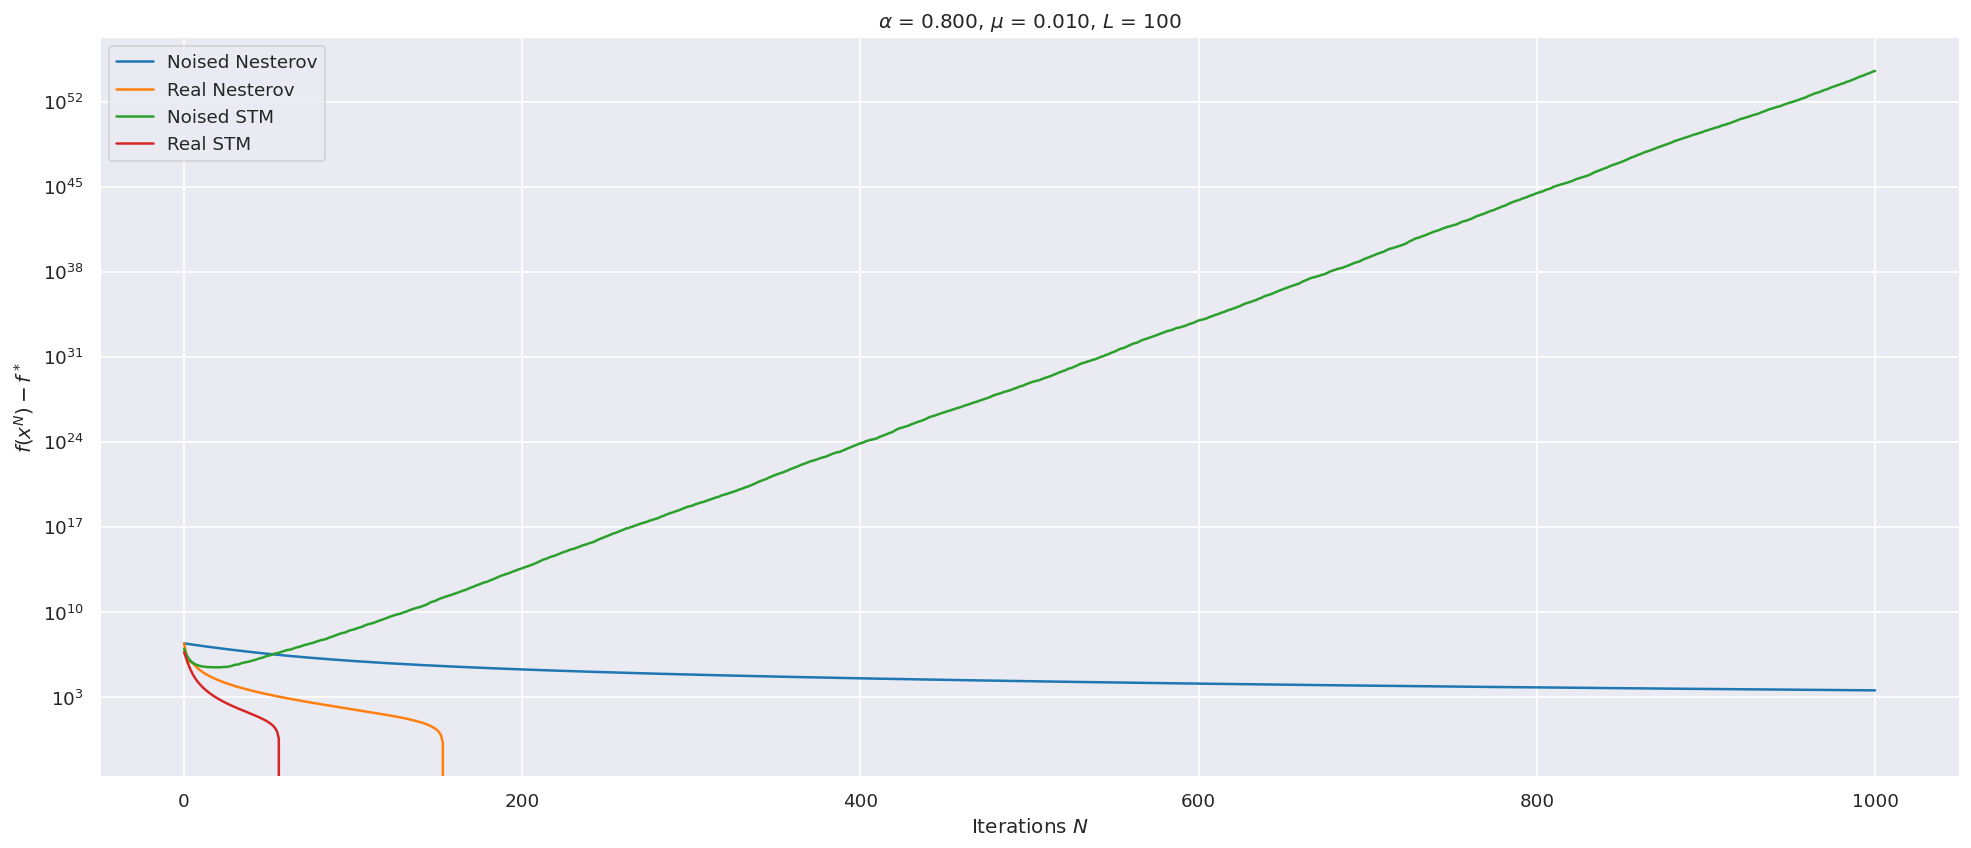

In [18]:
_ = plot(1000, alpha=0.8, mu=0.01, L=100)

In [ ]:
_ = plot(1000, alpha=0.75, mu=0.01, L=100)